# AutoSPECTRA — Week 6 Notebook
## Bidirectional LSTM Classification and Normal-Only LSTM Autoencoder

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Project:** AutoSPECTRA — Deep-Learning Intrusion Detection for the Connected Car  
**Group:** 7  
**Week:** 6 of 8

Week 6 implements the sequence-learning route using the protected `64 × 11` CAN windows from Week 3.

## Week 6 Scope

- Train a **Bidirectional LSTM** for five-class classification.
- Select its checkpoint using **validation macro-F1**.
- Train an **LSTM autoencoder on Normal training windows only**.
- Select autoencoder score direction and threshold on **validation data only**.
- Enforce a validation FPR constraint during threshold search.
- Evaluate both sequence approaches on the held-out test split.
- Save training, confusion, ROC, PR, reliability, anomaly-score and error-analysis images.
- Export prediction-level CSV files, metadata JSON files and Kaggle evidence ZIPs.

## Team Contributions

| Member | Name | Role | Week 6 Contribution |
|---|---|---|---|
| 1 | Amit Das | Protected Sequence Data & Split Integrity Lead | Revalidated the protected sequence arrays, class order and held-out test isolation |
| 2 | Aahmad Sayeed | CNN-to-Sequence Comparison Reviewer | Reviewed consistency between Week 5 CNN and Week 6 sequence-model evaluation |
| 3 | Maheswari Kamireddy | LSTM & Autoencoder Lead | Implemented the Bidirectional LSTM, normal-only autoencoder, training utilities, validation checkpointing, threshold selection and sequence-model evaluation |
| 4 | Miftha Thahniyath | Artifact, Error-Case & Demo-Handover Lead | Organised prediction manifests, model metadata, error evidence, Kaggle image/report exports and later demo handover |
| 5 | Nagireddy Nakka | Critical Evaluation & Responsible AI Lead | Reviewed false-negative risk, threshold governance, calibration, generalisation limits and responsible interpretation |

## Eight-Week Development Plan

| Week | Technical Evidence |
|---|---|
| Week 1 | Repository setup, architecture, roles and ethics baseline |
| Week 2 | Dataset acquisition, DLC-aware parsing, audit and EDA |
| Week 3 | Windowing, chronological split, leakage checks and representations |
| Week 4 | Classical machine-learning baselines |
| Week 5 | Recurrence-image encoder and CNN |
| **Week 6** | **Bidirectional LSTM and LSTM autoencoder** |
| Week 7 | Fusion, calibration, ablation, latency and cross-model evaluation |
| Week 8 | Incident reporting, Flask application and final integration |

## Week 6 Boundary

No RF/CNN/LSTM fusion, final temperature calibration, ablation suite or Flask deployment is performed here.

## Kaggle Instructions

1. Add Kaggle input: `pranavjha24/car-hacking-dataset`.
2. Enable a GPU when available.
3. Run this notebook from top to bottom.

Outputs:

```text
/kaggle/working/autospectra_week06_outputs/
```

Download after completion:

```text
/kaggle/working/AutoSPECTRA_Week06_Images.zip
/kaggle/working/AutoSPECTRA_Week06_Evidence.zip
```

In [86]:

# 1. Imports, reproducibility, and environment information

import os
import gc
import json
import math
import time
import random
import hashlib
import platform
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.utils.class_weight import compute_class_weight
import joblib


try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as xgboost_error:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable; continuing without it:", xgboost_error)


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42

def seed_everything(seed: int = SEED) -> None:
    """Make NumPy, Python, and PyTorch runs as reproducible as practical."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Week 6 Configuration

The Week 6 notebook keeps the authoritative 64-frame, stride-64, `source_class_chronological_v3` data configuration.

In [87]:

# 2. Experiment configuration


FAST_MODE = True

WINDOW_SIZE = 64
STRIDE = 64                 # Non-overlapping windows: prevents frame leakage.
CHUNK_SIZE = 400_000
TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15
MIN_ATTACK_FRAMES = 1

# Versioned strategy name is included in the cache hash. Therefore this
# corrected notebook cannot accidentally load the old normal-only test cache.
SPLIT_STRATEGY = "source_class_chronological_v3"
REBUILD_CACHE = False

if FAST_MODE:
    MAX_WINDOWS_PER_CLASS = {
        "train": 3_500,
        "validation": 800,
        "test": 800,
    }
    CLASSIFIER_EPOCHS = 8
    AUTOENCODER_EPOCHS = 8
    BATCH_SIZE = 256
    RF_TREES = 220
    ET_TREES = 220
    XGB_TREES = 260
else:
    MAX_WINDOWS_PER_CLASS = {
        "train": 12_000,
        "validation": 2_500,
        "test": 2_500,
    }
    CLASSIFIER_EPOCHS = 15
    AUTOENCODER_EPOCHS = 12
    BATCH_SIZE = 256
    RF_TREES = 400
    ET_TREES = 400
    XGB_TREES = 500

# Each source/class reservoir must be large enough to supply all three
# chronological partitions before the final per-class balancing step.
GROUP_RESERVOIR_CAPACITY = (
    sum(MAX_WINDOWS_PER_CLASS.values()) + 256
)

LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3
RUN_XGBOOST = False
RUN_DEEP_LEARNING = True
RUN_AUTOENCODER = True
RUN_FEATURE_ABLATION = False
RUN_EXPENSIVE_WINDOW_ABLATION = False

OUTPUT_DIR = Path("/kaggle/working/autospectra_week06_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in (PLOT_DIR, MODEL_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

FEATURE_NAMES = [
    "duration_s",
    "message_rate_hz",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_p95_ms",
    "iat_max_ms",
    "unique_id_count",
    "id_entropy",
    "max_id_ratio",
    "id_transition_rate",
    "can_id_mean_norm",
    "can_id_std_norm",
    "dominant_id_norm",
    "zero_id_ratio",
    "dlc_mean",
    "dlc_std",
    "payload_mean",
    "payload_std",
    "payload_entropy",
    "nonzero_byte_ratio",
    "byte_change_mean",
    "byte_change_std",
    "payload_sum_mean",
    "payload_sum_std",
]

CONFIG_FOR_CACHE = {
    "split_strategy": SPLIT_STRATEGY,
    "fast_mode": FAST_MODE,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_windows": MAX_WINDOWS_PER_CLASS,
    "group_reservoir_capacity": GROUP_RESERVOIR_CAPACITY,
    "min_attack_frames": MIN_ATTACK_FRAMES,
}
CONFIG_HASH = hashlib.md5(
    json.dumps(CONFIG_FOR_CACHE, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

CACHE_FILE = OUTPUT_DIR / f"window_cache_{CONFIG_HASH}.npz"
CACHE_META_FILE = OUTPUT_DIR / f"window_metadata_{CONFIG_HASH}.csv"

print(json.dumps(CONFIG_FOR_CACHE, indent=2))
print("Corrected cache:", CACHE_FILE)


{
  "split_strategy": "source_class_chronological_v3",
  "fast_mode": true,
  "window_size": 64,
  "stride": 64,
  "max_windows": {
    "train": 3500,
    "validation": 800,
    "test": 800
  },
  "group_reservoir_capacity": 5356,
  "min_attack_frames": 1
}
Corrected cache: /kaggle/working/autospectra_week06_outputs/window_cache_a6bed9825e.npz


## 3. Dataset Discovery

In [88]:

# 3. Dataset discovery


def locate_dataset_files(search_root: str = "/kaggle/input"):
    """Find the four expected HCRL Car-Hacking files anywhere below Kaggle input."""
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {filename.lower(): filename for filename in files}

        for attack_name, expected_filename in SOURCE_FILES.items():
            key = expected_filename.lower()
            if key in lower_to_original:
                found[attack_name] = Path(root) / lower_to_original[key]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal

DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = []
for attack_name, path in DATA_FILES.items():
    file_table.append({
        "Capture": attack_name,
        "Filename": path.name,
        "Path": str(path),
        "Size_MB": path.stat().st_size / (1024 ** 2),
    })

display(pd.DataFrame(file_table).sort_values("Capture"))
print("Optional normal file:", OPTIONAL_NORMAL_FILE)

,Capture,Filename,Path,Size_MB
0,DoS,DoS_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,181.254108
1,Fuzzy,Fuzzy_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,189.324157
2,Gear,gear_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,219.650663
3,RPM,RPM_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,228.483139


Optional normal file: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. Validated Parser, Windowing and Protected Split

In [89]:

# 4. Raw parsing, feature engineering, and corrected split builder


RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]

# Hash-map conversion is faster than repeatedly calling int(text, 16)
# for millions of payload values.
HEX_BYTE_MAP = {}
for value in range(256):
    for key in {
        f"{value:02x}", f"{value:02X}",
        f"{value:x}", f"{value:X}",
    }:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def fast_line_count(path: Path) -> int:
    """Count rows with buffered binary reads."""
    with path.open("rb") as handle:
        return sum(1 for _ in handle)


def shannon_entropy(values: np.ndarray) -> float:
    """Shannon entropy in bits for a one-dimensional integer array."""
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / max(counts.sum(), 1)
    return float(
        -(probabilities * np.log2(probabilities + 1e-12)).sum()
    )


def convert_chunk(chunk: pd.DataFrame):
    """
    Convert one flexible-width HCRL raw chunk into compact NumPy arrays.

    The attack flag is not in a fixed column: it occurs immediately after
    the number of bytes specified by DLC. Missing payload positions remain 0.
    """
    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_ids_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_ids_series.isna()
    if missing_ids.any():
        can_ids_series.loc[missing_ids] = (
            can_text.loc[missing_ids]
            .apply(lambda value: int(value, 16))
        )

    can_ids = (
        can_ids_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros(
        (len(chunk), 8),
        dtype=np.uint8,
    )

    for byte_index in range(8):
        text = (
            chunk[f"X{byte_index}"]
            .astype(str)
            .str.strip()
        )
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )
        valid = dlc > byte_index
        payload[valid, byte_index] = (
            numeric[valid].astype(np.uint8)
        )

    is_attack = np.zeros(
        len(chunk),
        dtype=bool,
    )

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask]
            .eq("T")
            .to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
    )


def build_sequence(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """
    Create the 64 x 11 sequence used by the CNN and LSTM.

    Channels:
      0    CAN ID / 2047
      1    DLC / 8
      2-9  payload bytes / 255
      10   log-scaled inter-arrival time
    """
    deltas = np.diff(
        timestamps,
        prepend=timestamps[0],
    )
    deltas = np.clip(deltas, 0, None)

    sequence = np.zeros(
        (len(timestamps), 11),
        dtype=np.float32,
    )

    sequence[:, 0] = np.clip(
        can_ids.astype(np.float32) / 2047.0,
        0,
        1,
    )
    sequence[:, 1] = (
        dlc.astype(np.float32) / 8.0
    )
    sequence[:, 2:10] = (
        payload.astype(np.float32) / 255.0
    )
    sequence[:, 10] = np.clip(
        np.log1p(deltas * 1_000_000.0) / 15.0,
        0,
        1,
    )

    return sequence.astype(np.float16)


def build_tabular_features(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """Engineer window features without flags, labels, or future values."""
    duration = max(
        float(timestamps[-1] - timestamps[0]),
        1e-9,
    )

    deltas = np.diff(timestamps)
    positive_deltas = np.clip(
        deltas,
        0,
        None,
    )
    iat_ms = positive_deltas * 1000.0

    unique_ids, id_counts = np.unique(
        can_ids,
        return_counts=True,
    )
    dominant_position = int(
        np.argmax(id_counts)
    )
    dominant_id = int(
        unique_ids[dominant_position]
    )
    max_id_ratio = float(
        id_counts[dominant_position]
        / len(can_ids)
    )

    payload_flat = payload.reshape(-1)

    if len(payload) > 1:
        payload_differences = np.abs(
            np.diff(
                payload.astype(np.float32),
                axis=0,
            )
        ).mean(axis=1)
    else:
        payload_differences = np.array(
            [0.0],
            dtype=np.float32,
        )

    payload_sums = (
        payload.sum(axis=1)
        .astype(np.float32)
    )

    return np.array([
        duration,
        len(timestamps) / duration,
        float(iat_ms.mean()) if len(iat_ms) else 0.0,
        float(iat_ms.std()) if len(iat_ms) else 0.0,
        float(np.percentile(iat_ms, 95)) if len(iat_ms) else 0.0,
        float(iat_ms.max()) if len(iat_ms) else 0.0,
        len(unique_ids),
        shannon_entropy(can_ids),
        max_id_ratio,
        (
            float(np.mean(can_ids[1:] != can_ids[:-1]))
            if len(can_ids) > 1
            else 0.0
        ),
        float(can_ids.mean() / 2047.0),
        float(can_ids.std() / 2047.0),
        dominant_id / 2047.0,
        float(np.mean(can_ids == 0)),
        float(dlc.mean()),
        float(dlc.std()),
        float(payload.mean()),
        float(payload.std()),
        shannon_entropy(payload_flat),
        float(np.mean(payload_flat != 0)),
        float(payload_differences.mean()),
        float(payload_differences.std()),
        float(payload_sums.mean()),
        float(payload_sums.std()),
    ], dtype=np.float32)


class Reservoir:
    """Deterministic fixed-capacity reservoir sampler."""

    def __init__(
        self,
        capacity: int,
        seed: int,
    ):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.seen = 0
        self.items = []

    def choose_slot(self):
        self.seen += 1

        if len(self.items) < self.capacity:
            return len(self.items)

        candidate = int(
            self.rng.integers(0, self.seen)
        )

        return (
            candidate
            if candidate < self.capacity
            else None
        )

    def store(
        self,
        slot: int,
        item: dict,
    ):
        if slot == len(self.items):
            self.items.append(item)
        else:
            self.items[slot] = item


def make_reservoirs():
    """
    Keep separate reservoirs for each source capture and each label.

    This is the core correction: sampling occurs across the full capture
    before any split is assigned. Consequently, later attack windows remain
    available for validation and testing.
    """
    reservoirs = {}

    for source_index, source_attack in enumerate(SOURCE_FILES):
        reservoirs[source_attack] = {}

        for local_index, class_name in enumerate(
            ["Normal", source_attack]
        ):
            reservoirs[source_attack][class_name] = Reservoir(
                GROUP_RESERVOIR_CAPACITY,
                SEED
                + source_index * 100
                + local_index,
            )

    return reservoirs


def process_capture(
    path: Path,
    source_attack: str,
    total_rows: int,
    reservoirs: dict,
    chunk_size: int = CHUNK_SIZE,
):
    """
    Stream one full capture and create non-overlapping candidate windows.

    No train/validation/test decision is made here. Windows are first sampled
    across the entire source/class timeline and split later.
    """
    print(
        f"\nProcessing {source_attack}: "
        f"{path.name} ({total_rows:,} rows)"
    )

    carry = None
    carry_global_start = 0
    global_chunk_start = 0
    next_window_start = 0
    processed_windows = 0
    accepted_windows = 0

    reader = pd.read_csv(
        path,
        header=None,
        names=RAW_COLUMNS,
        dtype=str,
        chunksize=chunk_size,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(
        reader,
        start=1,
    ):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
        ) = convert_chunk(chunk)

        current_length = len(timestamps)

        if carry is None:
            combined = (
                timestamps,
                can_ids,
                dlc,
                payload,
                flags,
            )
            combined_global_start = (
                global_chunk_start
            )
        else:
            combined = (
                np.concatenate(
                    [carry[0], timestamps]
                ),
                np.concatenate(
                    [carry[1], can_ids]
                ),
                np.concatenate(
                    [carry[2], dlc]
                ),
                np.concatenate(
                    [carry[3], payload],
                    axis=0,
                ),
                np.concatenate(
                    [carry[4], flags]
                ),
            )
            combined_global_start = (
                carry_global_start
            )

        combined_end_global = (
            combined_global_start
            + len(combined[0])
        )

        if next_window_start < combined_global_start:
            next_window_start = (
                combined_global_start
            )

        while (
            next_window_start + WINDOW_SIZE
            <= combined_end_global
        ):
            local_start = (
                next_window_start
                - combined_global_start
            )
            local_end = (
                local_start + WINDOW_SIZE
            )

            window_flags = combined[4][
                local_start:local_end
            ]
            attack_count = int(
                window_flags.sum()
            )

            if attack_count >= MIN_ATTACK_FRAMES:
                class_name = source_attack
                first_attack_position = int(
                    np.flatnonzero(
                        window_flags
                    )[0]
                )
            else:
                class_name = "Normal"
                first_attack_position = -1

            reservoir = reservoirs[
                source_attack
            ][class_name]

            selected_slot = (
                reservoir.choose_slot()
            )

            if selected_slot is not None:
                win_ts = combined[0][
                    local_start:local_end
                ]
                win_ids = combined[1][
                    local_start:local_end
                ]
                win_dlc = combined[2][
                    local_start:local_end
                ]
                win_payload = combined[3][
                    local_start:local_end
                ]

                features = build_tabular_features(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )
                sequence = build_sequence(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )

                if first_attack_position >= 0:
                    latency_upper_bound_ms = float(
                        (
                            win_ts[-1]
                            - win_ts[
                                first_attack_position
                            ]
                        )
                        * 1000.0
                    )
                else:
                    latency_upper_bound_ms = np.nan

                unique_ids, counts = np.unique(
                    win_ids,
                    return_counts=True,
                )
                dominant_id = int(
                    unique_ids[
                        np.argmax(counts)
                    ]
                )

                item = {
                    "sequence": sequence,
                    "features": features,
                    "label": CLASS_TO_INDEX[
                        class_name
                    ],
                    "metadata": {
                        "split": "unassigned",
                        "class_name": class_name,
                        "source_capture": source_attack,
                        "start_timestamp":
                            float(win_ts[0]),
                        "end_timestamp":
                            float(win_ts[-1]),
                        "global_start_row":
                            int(next_window_start),
                        "attack_frame_count":
                            attack_count,
                        "attack_ratio":
                            attack_count / WINDOW_SIZE,
                        "first_attack_position":
                            first_attack_position,
                        "latency_upper_bound_ms":
                            latency_upper_bound_ms,
                        "dominant_can_id":
                            dominant_id,
                        "dominant_can_id_hex":
                            f"0x{dominant_id:03X}",
                    },
                }

                reservoir.store(
                    selected_slot,
                    item,
                )
                accepted_windows += 1

            processed_windows += 1
            next_window_start += STRIDE

        keep = min(
            WINDOW_SIZE - 1,
            len(combined[0]),
        )

        carry = (
            combined[0][-keep:].copy(),
            combined[1][-keep:].copy(),
            combined[2][-keep:].copy(),
            combined[3][-keep:].copy(),
            combined[4][-keep:].copy(),
        )
        carry_global_start = (
            combined_end_global - keep
        )
        global_chunk_start += current_length

        if chunk_number % 5 == 0:
            print(
                f"  chunk {chunk_number:>2} | "
                f"rows read {global_chunk_start:,} | "
                f"candidate windows "
                f"{processed_windows:,} | "
                f"reservoir writes "
                f"{accepted_windows:,}"
            )

        del (
            chunk,
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
            combined,
        )
        gc.collect()

    print(
        f"Finished {source_attack}: "
        f"{processed_windows:,} candidate windows, "
        f"{accepted_windows:,} reservoir writes."
    )


def chronological_partition(
    items,
):
    """
    Divide one source/class group chronologically.

    Because windows are non-overlapping, boundaries do not share CAN frames.
    At least one item is retained in every split when the group has >= 3.
    """
    items = sorted(
        items,
        key=lambda item:
            item["metadata"]["global_start_row"],
    )

    number_of_items = len(items)

    if number_of_items < 3:
        raise RuntimeError(
            "A source/class group has fewer than three sampled "
            f"windows ({number_of_items}); cannot form all splits."
        )

    train_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * TRAIN_FRACTION
            )
        ),
    )

    validation_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * VALID_FRACTION
            )
        ),
    )

    # Reserve at least one item for test.
    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        validation_count = max(
            1,
            number_of_items
            - train_count
            - 1,
        )

    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        train_count = max(
            1,
            number_of_items
            - validation_count
            - 1,
        )

    train_end = train_count
    validation_end = (
        train_count + validation_count
    )

    partitions = {
        "train": items[:train_end],
        "validation":
            items[train_end:validation_end],
        "test":
            items[validation_end:],
    }

    if any(
        len(partition) == 0
        for partition in partitions.values()
    ):
        raise RuntimeError(
            "Chronological partition created an empty split."
        )

    return partitions


def deterministic_cap(
    items,
    capacity,
    seed,
):
    """Select a reproducible subset while retaining broad time coverage."""
    if len(items) <= capacity:
        return list(items)

    ordered = sorted(
        items,
        key=lambda item: (
            item["metadata"]["source_capture"],
            item["metadata"]["global_start_row"],
        ),
    )

    # Evenly spaced selection gives coverage across the complete period
    # instead of concentrating on one short interval.
    positions = np.linspace(
        0,
        len(ordered) - 1,
        num=capacity,
        dtype=int,
    )

    return [
        ordered[position]
        for position in positions
    ]


def finalise_reservoirs(
    reservoirs,
):
    """
    Build balanced train/validation/test arrays with every class present.

    Splitting is chronological inside each source/class group. Final caps are
    applied only after these partitions have been formed.
    """
    grouped_split_items = {
        split_name: {
            class_name: []
            for class_name in CLASS_NAMES
        }
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    group_summary = []

    for source_attack in SOURCE_FILES:
        for class_name in [
            "Normal",
            source_attack,
        ]:
            group_items = reservoirs[
                source_attack
            ][class_name].items

            partitions = chronological_partition(
                group_items
            )

            group_summary.append({
                "Source_Capture":
                    source_attack,
                "Class":
                    class_name,
                "Sampled_Total":
                    len(group_items),
                "Train":
                    len(partitions["train"]),
                "Validation":
                    len(partitions["validation"]),
                "Test":
                    len(partitions["test"]),
            })

            for (
                split_name,
                split_items,
            ) in partitions.items():
                for item in split_items:
                    item["metadata"][
                        "split"
                    ] = split_name

                grouped_split_items[
                    split_name
                ][class_name].extend(
                    split_items
                )

    group_summary_df = pd.DataFrame(
        group_summary
    )
    print(
        "\nSource/class chronological "
        "partition summary:"
    )
    display(group_summary_df)

    output = {}

    for split_index, split_name in enumerate(
        ["train", "validation", "test"]
    ):
        selected_items = []

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            class_items = grouped_split_items[
                split_name
            ][class_name]

            if not class_items:
                raise RuntimeError(
                    f"No {class_name} windows were available "
                    f"for split '{split_name}'."
                )

            class_items = deterministic_cap(
                class_items,
                MAX_WINDOWS_PER_CLASS[
                    split_name
                ],
                SEED
                + split_index * 100
                + class_index,
            )

            selected_items.extend(
                class_items
            )

        rng = np.random.default_rng(
            SEED + split_index
        )
        rng.shuffle(selected_items)

        sequences = np.stack([
            item["sequence"]
            for item in selected_items
        ]).astype(np.float16)

        features = np.stack([
            item["features"]
            for item in selected_items
        ]).astype(np.float32)

        labels = np.array([
            item["label"]
            for item in selected_items
        ], dtype=np.int64)

        metadata = pd.DataFrame([
            item["metadata"]
            for item in selected_items
        ])

        output[split_name] = {
            "sequences": sequences,
            "features": features,
            "labels": labels,
            "metadata": metadata,
        }

    return output


## 5. Build or Load the Versioned Cache

In [90]:

# 5. Build/load cache


def save_window_cache(data):
    np.savez_compressed(
        CACHE_FILE,
        train_sequences=data["train"]["sequences"],
        train_features=data["train"]["features"],
        train_labels=data["train"]["labels"],
        validation_sequences=data["validation"]["sequences"],
        validation_features=data["validation"]["features"],
        validation_labels=data["validation"]["labels"],
        test_sequences=data["test"]["sequences"],
        test_features=data["test"]["features"],
        test_labels=data["test"]["labels"],
    )

    metadata_frames = []

    for split_name in ["train", "validation", "test"]:
        frame = data[split_name]["metadata"].copy()
        frame["cache_split"] = split_name
        frame["cache_row"] = np.arange(len(frame))
        metadata_frames.append(frame)

    pd.concat(
        metadata_frames, ignore_index=True
    ).to_csv(CACHE_META_FILE, index=False)

    with (
        OUTPUT_DIR / f"config_{CONFIG_HASH}.json"
    ).open("w") as handle:
        json.dump(CONFIG_FOR_CACHE, handle, indent=2)


def load_window_cache():
    arrays = np.load(CACHE_FILE, allow_pickle=False)
    metadata = pd.read_csv(CACHE_META_FILE)

    data = {}

    for split_name in ["train", "validation", "test"]:
        split_metadata = (
            metadata[
                metadata["cache_split"] == split_name
            ]
            .sort_values("cache_row")
            .reset_index(drop=True)
        )

        data[split_name] = {
            "sequences":
                arrays[f"{split_name}_sequences"],
            "features":
                arrays[f"{split_name}_features"],
            "labels":
                arrays[f"{split_name}_labels"],
            "metadata": split_metadata,
        }

    return data


if (
    CACHE_FILE.exists()
    and CACHE_META_FILE.exists()
    and not REBUILD_CACHE
):
    print("Loading corrected source/class chronological cache...")
    DATA = load_window_cache()
else:
    print("Counting rows before corrected source/class chronological extraction...")

    ROW_COUNTS = {
        attack_name: fast_line_count(path)
        for attack_name, path in DATA_FILES.items()
    }

    display(pd.DataFrame([
        {"Capture": name, "Rows": count}
        for name, count in ROW_COUNTS.items()
    ]))

    reservoirs = make_reservoirs()

    for source_attack, path in DATA_FILES.items():
        process_capture(
            path=path,
            source_attack=source_attack,
            total_rows=ROW_COUNTS[source_attack],
            reservoirs=reservoirs,
        )

    DATA = finalise_reservoirs(reservoirs)
    save_window_cache(DATA)


for split_name, split_data in DATA.items():
    print(
        split_name,
        "| sequences:", split_data["sequences"].shape,
        "| features:", split_data["features"].shape,
        "| labels:", split_data["labels"].shape,
    )

Loading corrected source/class chronological cache...
train | sequences: (17500, 64, 11) | features: (17500, 24) | labels: (17500,)
validation | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)
test | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)


In [91]:
# Validate class coverage and confirm that labels are never features.
summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    counts = (
        pd.Series(
            DATA[split_name]["labels"]
        )
        .value_counts()
        .sort_index()
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        summary_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Windows": int(
                counts.get(
                    class_index,
                    0,
                )
            ),
        })

split_class_counts = pd.DataFrame(
    summary_rows
)

coverage_table = (
    split_class_counts
    .pivot(
        index="Class",
        columns="Split",
        values="Windows",
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(coverage_table)

missing_pairs = [
    f"{class_name} in {split_name}"
    for class_name in CLASS_NAMES
    for split_name in [
        "train",
        "validation",
        "test",
    ]
    if coverage_table.loc[
        class_name,
        split_name,
    ] == 0
]

if missing_pairs:
    raise RuntimeError(
        "Invalid class coverage: "
        + ", ".join(missing_pairs)
        + ". Delete old caches or set REBUILD_CACHE=True, "
        "then rerun from the configuration cell."
    )

expected_class_indices = set(
    range(len(CLASS_NAMES))
)

for split_name in [
    "train",
    "validation",
    "test",
]:
    observed = set(
        np.unique(
            DATA[split_name]["labels"]
        )
    )

    if observed != expected_class_indices:
        raise RuntimeError(
            f"Split '{split_name}' contains labels "
            f"{sorted(observed)}, expected "
            f"{sorted(expected_class_indices)}."
        )

assert (
    DATA["train"]["features"].shape[1]
    == len(FEATURE_NAMES)
)

assert not any(
    "label" in name.lower()
    or "flag" in name.lower()
    or "attack_frame" in name.lower()
    for name in FEATURE_NAMES
)

assert STRIDE >= WINDOW_SIZE, (
    "Use non-overlapping windows to avoid shared-frame leakage."
)

print(
    "Coverage audit passed: all five classes occur in "
    "train, validation, and unseen test sets."
)
print(
    "Feature audit passed: no target or attack-flag feature "
    "is used by any model."
)


Split,test,train,validation
Class,,,
Normal,800,3500,800
DoS,800,3500,800
Fuzzy,800,3500,800
Gear,800,3500,800
RPM,800,3500,800


Coverage audit passed: all five classes occur in train, validation, and unseen test sets.
Feature audit passed: no target or attack-flag feature is used by any model.


In [92]:
# 6. Figure helper

def save_current_figure(filename: str):
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Part A — Sequence Data and Evaluation Harness

In [93]:

# 7. Evaluation utilities


X_train_tab = DATA[
    "train"
]["features"].astype(np.float32)
y_train = DATA["train"]["labels"]

X_validation_tab = DATA[
    "validation"
]["features"].astype(np.float32)
y_validation = DATA["validation"]["labels"]

X_test_tab = DATA[
    "test"
]["features"].astype(np.float32)
y_test = DATA["test"]["labels"]

X_train_seq = DATA["train"]["sequences"]
X_validation_seq = DATA["validation"]["sequences"]
X_test_seq = DATA["test"]["sequences"]

evaluation_rows = []
prediction_store = {}


def expected_calibration_error(
    y_true,
    probabilities,
    bins: int = 10,
) -> float:
    """ECE based on confidence of the selected multiclass prediction."""
    predictions = probabilities.argmax(axis=1)
    confidences = probabilities.max(axis=1)
    correctness = predictions == y_true

    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences >= lower)
                & (confidences < upper)
            )

        if mask.any():
            bin_accuracy = correctness[mask].mean()
            bin_confidence = confidences[mask].mean()

            ece += (
                mask.mean()
                * abs(
                    bin_accuracy
                    - bin_confidence
                )
            )

    return float(ece)


def model_file_size_mb(path: Path) -> float:
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return np.nan


def calculate_multiclass_metrics(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_size_mb=np.nan,
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    observed_classes = set(np.unique(y_true))
    expected_classes = set(range(len(CLASS_NAMES)))

    if observed_classes != expected_classes:
        raise ValueError(
            f"{model_name}: test set class coverage is invalid. "
            f"Observed {sorted(observed_classes)}, "
            f"expected {sorted(expected_classes)}."
        )

    if probabilities.shape != (
        len(y_true),
        len(CLASS_NAMES),
    ):
        raise ValueError(
            f"{model_name}: probability shape "
            f"{probabilities.shape} does not match "
            f"({len(y_true)}, {len(CLASS_NAMES)})."
        )

    predictions = probabilities.argmax(axis=1)

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        predictions,
        average="weighted",
        zero_division=0,
    )

    binary_true = (
        y_true
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    binary_prediction = (
        predictions
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        binary_true,
        binary_prediction,
        labels=[0, 1],
    ).ravel()

    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    try:
        macro_roc_auc = roc_auc_score(
            y_true,
            probabilities,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = average_precision_score(
            y_binary,
            probabilities,
            average="macro",
        )
    except ValueError:
        macro_pr_auc = np.nan

    row = {
        "Model": model_name,
        "Accuracy":
            accuracy_score(y_true, predictions),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "MCC":
            matthews_corrcoef(
                y_true,
                predictions,
            ),
        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
            ),
        "Macro_ROC_AUC_OVR": macro_roc_auc,
        "Macro_PR_AUC": macro_pr_auc,
        "Attack_FPR":
            fp / max(fp + tn, 1),
        "Attack_FNR":
            fn / max(fn + tp, 1),
        "ECE_10_bins":
            expected_calibration_error(
                y_true,
                probabilities,
                bins=10,
            ),
        "Inference_ms_per_window":
            inference_seconds
            * 1000.0
            / len(y_true),
        "Throughput_windows_per_second":
            len(y_true)
            / max(inference_seconds, 1e-9),
        "Model_Size_MB": model_size_mb,
    }

    return row, predictions


def plot_confusion(
    y_true,
    predictions,
    model_name,
):
    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(8, 7))

    image = plt.imshow(
        matrix,
        aspect="auto",
    )

    plt.colorbar(
        image,
        label="Window count",
    )

    plt.xticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
        rotation=45,
    )

    plt.yticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
    )

    threshold = matrix.max() / 2.0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(
                column,
                row,
                f"{matrix[row, column]:,}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    plt.title(
        f"Confusion matrix — {model_name}"
    )
    plt.xlabel("Predicted class")
    plt.ylabel("True class")

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_confusion_{safe_name}.png"
    )


def plot_roc_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        (
            false_positive_rate,
            true_positive_rate,
            _,
        ) = roc_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            false_positive_rate,
            true_positive_rate,
        )

        plt.plot(
            false_positive_rate,
            true_positive_rate,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )

    plt.title(
        f"One-vs-rest ROC curves — {model_name}"
    )
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_roc_{safe_name}.png"
    )


def plot_precision_recall_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        precision, recall, _ = precision_recall_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            recall,
            precision,
        )

        plt.plot(
            recall,
            precision,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.title(
        "One-vs-rest precision–recall curves "
        f"— {model_name}"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_pr_{safe_name}.png"
    )


def plot_reliability(
    y_true,
    probabilities,
    model_name,
    bins=10,
):
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = (
        predictions == y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        bins + 1,
    )

    mean_confidence = []
    empirical_accuracy = []

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if mask.any():
            mean_confidence.append(
                confidence[mask].mean()
            )
            empirical_accuracy.append(
                correctness[mask].mean()
            )

    plt.figure(figsize=(7, 6))

    plt.plot(
        mean_confidence,
        empirical_accuracy,
        marker="o",
        label=model_name,
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.title(
        f"Reliability diagram — {model_name}"
    )
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Observed accuracy")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_calibration_{safe_name}.png"
    )


def evaluate_and_store(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_path=None,
    make_all_plots=True,
):
    size_mb = (
        model_file_size_mb(model_path)
        if model_path
        else np.nan
    )

    metric_row, predictions = (
        calculate_multiclass_metrics(
            model_name,
            y_true,
            probabilities,
            inference_seconds,
            size_mb,
        )
    )

    evaluation_rows.append(metric_row)

    prediction_store[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions,
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))

    display(
        pd.DataFrame([metric_row])
        .T
        .rename(columns={0: "Value"})
    )

    display(
        pd.DataFrame(
            classification_report(
                y_true,
                predictions,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).T
    )

    plot_confusion(
        y_true,
        predictions,
        model_name,
    )

    if make_all_plots:
        plot_roc_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_precision_recall_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_reliability(
            y_true,
            probabilities,
            model_name,
        )

    return metric_row, predictions

In [94]:
# 7. Week 6 sequence-array audit

metadata_test = DATA["test"]["metadata"].copy()

sequence_audit_df = pd.DataFrame([
    {"Split":"Train","Shape":str(tuple(X_train_seq.shape)),"Windows":len(y_train)},
    {"Split":"Validation","Shape":str(tuple(X_validation_seq.shape)),"Windows":len(y_validation)},
    {"Split":"Test","Shape":str(tuple(X_test_seq.shape)),"Windows":len(y_test)},
])
display(sequence_audit_df)

for sequences, labels in [
    (X_train_seq, y_train),
    (X_validation_seq, y_validation),
    (X_test_seq, y_test),
]:
    assert sequences.shape[1:] == (WINDOW_SIZE, 11)
    assert len(sequences) == len(labels)
    assert np.isfinite(sequences).all()
    assert sequences.min() >= 0
    assert sequences.max() <= 1

sequence_audit_df.to_csv(
    REPORT_DIR / "week06_sequence_audit.csv",
    index=False,
)
print("Sequence audit passed.")

,Split,Shape,Windows
0,Train,"(17500, 64, 11)",17500
1,Validation,"(4000, 64, 11)",4000
2,Test,"(4000, 64, 11)",4000


Sequence audit passed.


In [ ]:
# 8. Save one chronological sequence example per class

fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 14), sharex=True)

for class_index, class_name in enumerate(CLASS_NAMES):
    index = int(np.flatnonzero(y_train == class_index)[0])
    sequence = X_train_seq[index].astype(np.float32)

    can_id = np.rint(sequence[:, 0] * 2047).astype(int)
    payload_mean = sequence[:, 2:10].mean(axis=1)
    timing = sequence[:, 10]
    x = np.arange(WINDOW_SIZE)

    axes[class_index].plot(x, can_id, label="CAN ID")
    axes[class_index].set_title(class_name)
    axes[class_index].set_ylabel("CAN ID")
    axes[class_index].grid(alpha=0.2)

    second = axes[class_index].twinx()
    second.plot(x, payload_mean, linestyle="--", label="Mean payload")
    second.plot(x, timing, linestyle=":", label="Timing")
    second.set_ylabel("Normalised value")

axes[-1].set_xlabel("Frame position")
fig.suptitle("Week 6 sequence examples")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "week06_sequence_examples.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Part B — Bidirectional LSTM Classifier

In [ ]:
# 9. Sequence dataset, Bidirectional LSTM and data loader

class CANSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        sequence = torch.from_numpy(
            self.sequences[index].astype(np.float32)
        )
        label = torch.tensor(
            int(self.labels[index]),
            dtype=torch.long,
        )
        return sequence, label


class CANLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size=11,
        hidden_size=64,
        number_of_classes=len(CLASS_NAMES),
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Dropout(0.25),
            nn.Linear(hidden_size * 2, number_of_classes),
        )

    def forward(self, inputs):
        outputs, _ = self.lstm(inputs)
        representation = outputs.mean(dim=1)
        return self.classifier(representation)


def create_loader(dataset, shuffle=False, batch_size=BATCH_SIZE):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

lstm_architecture = CANLSTMClassifier()
lstm_parameter_count = sum(
    p.numel() for p in lstm_architecture.parameters()
)
print(lstm_architecture)
print("LSTM parameters:", f"{lstm_parameter_count:,}")

In [ ]:

# 10. Generic classifier training and probability prediction


def probabilities_from_torch_model(
    model,
    loader,
):
    model.eval()

    probability_batches = []
    label_batches = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(inputs)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            label_batches.append(
                labels.numpy()
            )

    return (
        np.concatenate(probability_batches),
        np.concatenate(label_batches),
    )


def train_torch_classifier(
    model,
    train_loader,
    validation_loader,
    model_name,
    epochs=CLASSIFIER_EPOCHS,
):
    class_values = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=class_values,
        y=y_train,
    )

    complete_weights = np.ones(
        len(CLASS_NAMES),
        dtype=np.float32,
    )

    complete_weights[
        class_values
    ] = weights.astype(np.float32)

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            complete_weights,
            device=DEVICE,
        ),
        label_smoothing=0.02,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )

    model = model.to(DEVICE)

    best_state = None
    best_macro_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        seen = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0,
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * len(labels)
            )

            seen += len(labels)

        (
            validation_probabilities,
            validation_labels,
        ) = probabilities_from_torch_model(
            model,
            validation_loader,
        )

        validation_predictions = (
            validation_probabilities.argmax(
                axis=1
            )
        )

        validation_macro_f1 = f1_score(
            validation_labels,
            validation_predictions,
            average="macro",
            zero_division=0,
        )

        epoch_loss = (
            running_loss
            / max(seen, 1)
        )

        history.append({
            "epoch": epoch,
            "training_loss": epoch_loss,
            "validation_macro_f1":
                validation_macro_f1,
        })

        print(
            f"{model_name} | "
            f"epoch {epoch:02d} | "
            f"loss {epoch_loss:.4f} | "
            f"validation macro-F1 "
            f"{validation_macro_f1:.4f}"
        )

        if (
            validation_macro_f1
            > best_macro_f1 + 1e-4
        ):
            best_macro_f1 = (
                validation_macro_f1
            )

            best_state = {
                key:
                    value
                    .detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return model, pd.DataFrame(history)


def plot_training_history(
    history,
    model_name,
):
    fig, first_axis = plt.subplots(
        figsize=(9, 5)
    )

    first_axis.plot(
        history["epoch"],
        history["training_loss"],
        marker="o",
        label="Training loss",
    )

    first_axis.set_xlabel("Epoch")
    first_axis.set_ylabel(
        "Cross-entropy loss"
    )

    second_axis = first_axis.twinx()

    second_axis.plot(
        history["epoch"],
        history["validation_macro_f1"],
        marker="s",
        linestyle="--",
        label="Validation macro-F1",
    )

    second_axis.set_ylabel(
        "Validation macro-F1"
    )

    plt.title(
        f"Training history — {model_name}"
    )

    path = (
        PLOT_DIR
        / (
            "training_"
            + model_name
            .lower()
            .replace(" ", "_")
            + ".png"
        )
    )

    plt.savefig(
        path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()
    print("Saved:", path)

In [ ]:
# 10. Week 6 deep-model stores

deep_validation_probabilities = {}
deep_test_probabilities = {}

LSTM Classifier | epoch 04 | loss 0.1290 | validation macro-F1 0.9960
LSTM Classifier | epoch 05 | loss 0.1260 | validation macro-F1 0.9963
Early stopping.


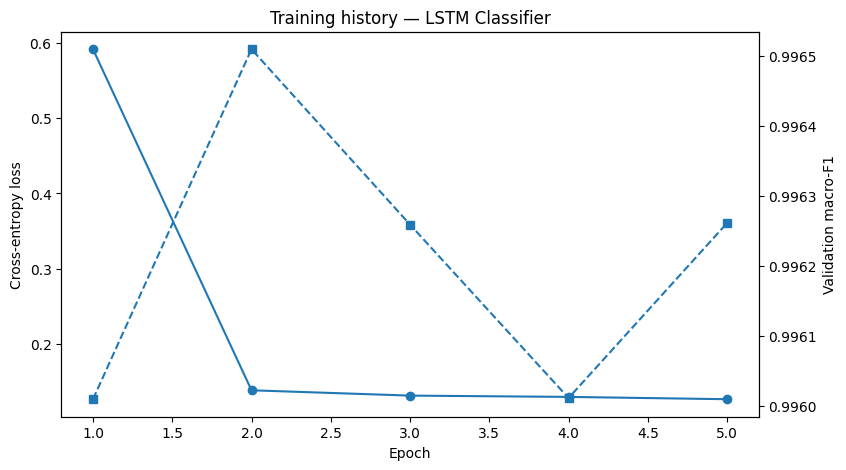

Saved: /kaggle/working/autospectra_week06_outputs/plots/training_lstm_classifier.png

LSTM Classifier
---------------


,Value
Model,LSTM Classifier
Accuracy,0.9955
Balanced_Accuracy,0.9955
Macro_Precision,0.995599
Macro_Recall,0.9955
Macro_F1,0.995518
Weighted_F1,0.995518
MCC,0.994391
Log_Loss,0.037209
Macro_ROC_AUC_OVR,0.999687


,precision,recall,f1-score,support
Normal,0.977995,1.00000,0.988875,800.0000
DoS,1.000000,0.99125,0.995606,800.0000
Fuzzy,1.000000,0.99375,0.996865,800.0000
Gear,1.000000,0.99500,0.997494,800.0000
RPM,1.000000,0.99750,0.998748,800.0000
accuracy,0.995500,0.99550,0.995500,0.9955
macro avg,0.995599,0.99550,0.995518,4000.0000
weighted avg,0.995599,0.99550,0.995518,4000.0000


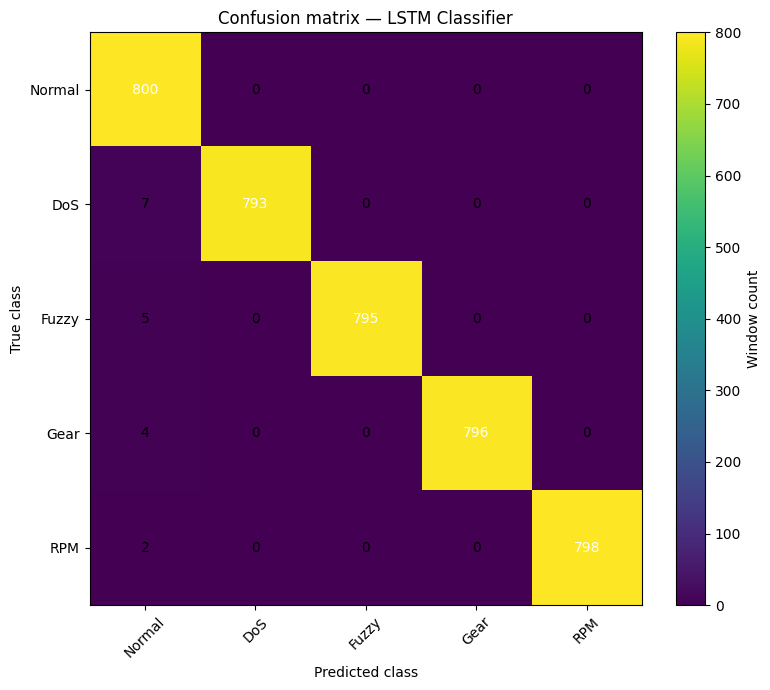

Saved: /kaggle/working/autospectra_week06_outputs/plots/metrics_confusion_lstm_classifier.png


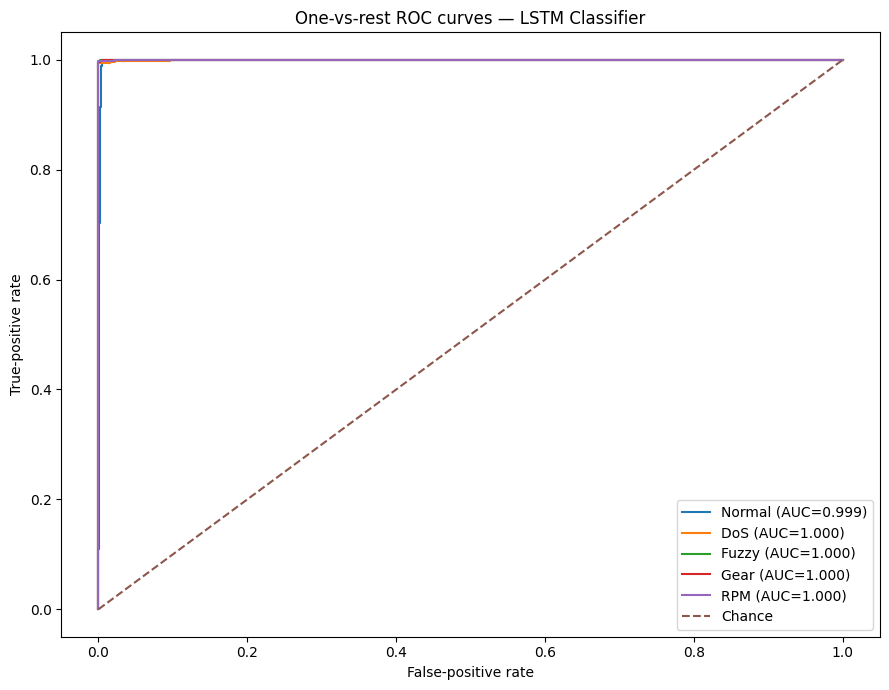

Saved: /kaggle/working/autospectra_week06_outputs/plots/metrics_roc_lstm_classifier.png


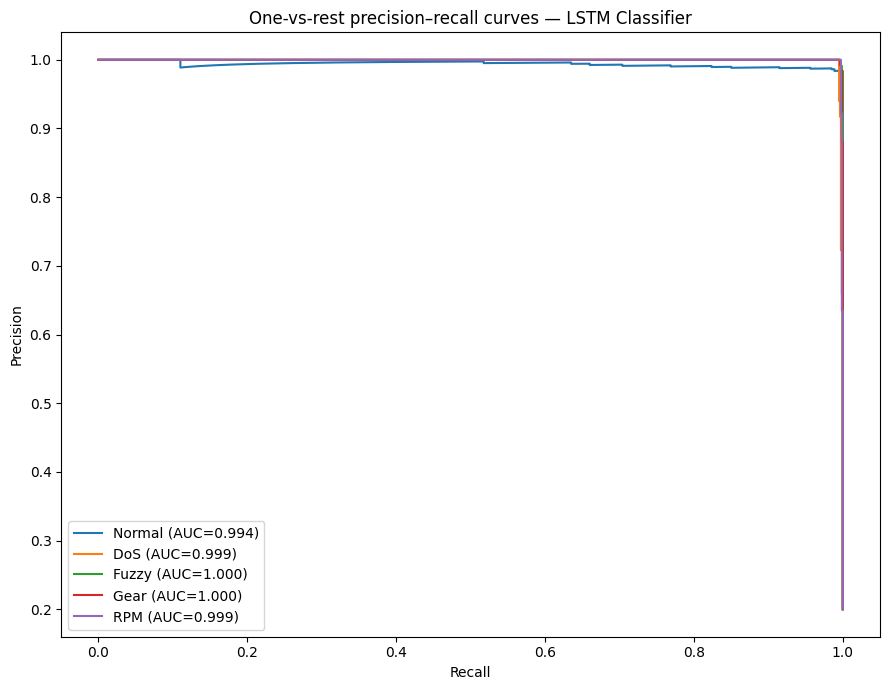

Saved: /kaggle/working/autospectra_week06_outputs/plots/metrics_pr_lstm_classifier.png


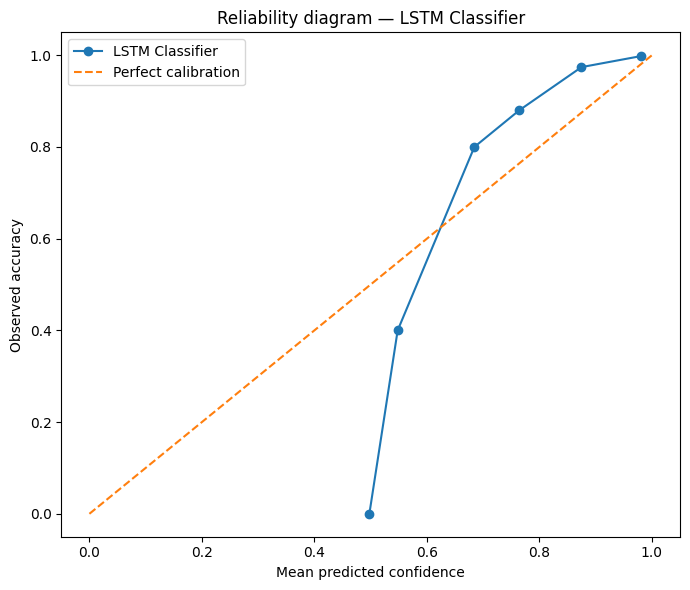

Saved: /kaggle/working/autospectra_week06_outputs/plots/metrics_calibration_lstm_classifier.png


In [99]:

# 12. Train and evaluate the LSTM classifier


if RUN_DEEP_LEARNING:
    lstm_train_dataset = CANSequenceDataset(
        X_train_seq,
        y_train,
    )

    lstm_validation_dataset = CANSequenceDataset(
        X_validation_seq,
        y_validation,
    )

    lstm_test_dataset = CANSequenceDataset(
        X_test_seq,
        y_test,
    )

    lstm_train_loader = create_loader(
        lstm_train_dataset,
        shuffle=True,
    )

    lstm_validation_loader = create_loader(
        lstm_validation_dataset
    )

    lstm_test_loader = create_loader(
        lstm_test_dataset
    )

    lstm_classifier = (
        CANLSTMClassifier()
    )

    fit_start = time.perf_counter()

    (
        lstm_classifier,
        lstm_history,
    ) = train_torch_classifier(
        lstm_classifier,
        lstm_train_loader,
        lstm_validation_loader,
        "LSTM Classifier",
    )

    lstm_fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    plot_training_history(
        lstm_history,
        "LSTM Classifier",
    )

    lstm_path = (
        MODEL_DIR
        / "lstm_classifier.pt"
    )

    torch.save({
        "state_dict":
            lstm_classifier.state_dict(),
        "class_names": CLASS_NAMES,
        "window_size": WINDOW_SIZE,
        "input_size": 11,
    }, lstm_path)

    (
        lstm_validation_probabilities,
        lstm_validation_labels,
    ) = probabilities_from_torch_model(
        lstm_classifier,
        lstm_validation_loader,
    )

    assert np.array_equal(
        lstm_validation_labels,
        y_validation,
    )

    inference_start = time.perf_counter()

    (
        lstm_test_probabilities,
        lstm_test_labels,
    ) = probabilities_from_torch_model(
        lstm_classifier,
        lstm_test_loader,
    )

    lstm_inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    assert np.array_equal(
        lstm_test_labels,
        y_test,
    )

    deep_validation_probabilities[
        "LSTM Classifier"
    ] = lstm_validation_probabilities

    deep_test_probabilities[
        "LSTM Classifier"
    ] = lstm_test_probabilities

    row, _ = evaluate_and_store(
        "LSTM Classifier",
        y_test,
        lstm_test_probabilities,
        lstm_inference_seconds,
        lstm_path,
        make_all_plots=True,
    )

    row[
        "Training_Seconds"
    ] = lstm_fit_seconds

,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,MCC,Log_Loss,Macro_ROC_AUC_OVR,Macro_PR_AUC,Attack_FPR,Attack_FNR,ECE_10_bins,Inference_ms_per_window,Throughput_windows_per_second,Model_Size_MB,Training_Seconds
0,LSTM Classifier,0.9955,0.9955,0.995599,0.9955,0.995518,0.995518,0.994391,0.037209,0.999687,0.998449,0.0,0.005625,0.020961,0.040892,24454.932717,0.157395,3.611587


,Class,Precision,Recall,F1,Support
0,Normal,0.977995,1.00000,0.988875,800
1,DoS,1.000000,0.99125,0.995606,800
2,Fuzzy,1.000000,0.99375,0.996865,800
3,Gear,1.000000,0.99500,0.997494,800
4,RPM,1.000000,0.99750,0.998748,800


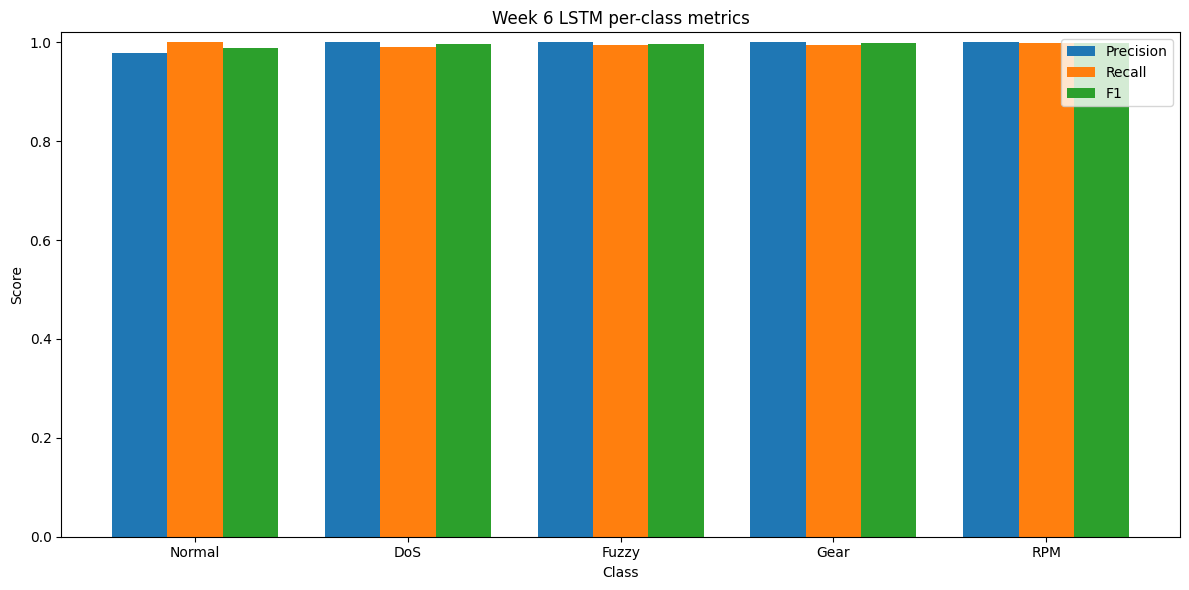

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_lstm_per_class_metrics.png


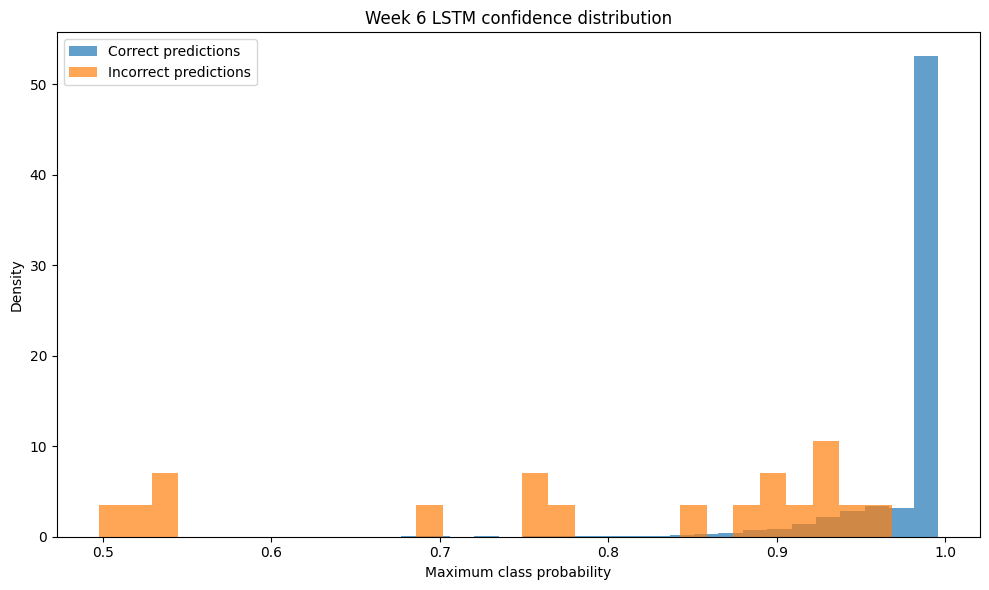

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_lstm_confidence_distribution.png


In [100]:
# 11. Export LSTM metrics, per-class metrics and prediction manifest

lstm_metrics_df = pd.DataFrame([
    row for row in evaluation_rows
    if row["Model"] == "LSTM Classifier"
])
display(lstm_metrics_df)
lstm_metrics_df.to_csv(
    REPORT_DIR / "week06_lstm_metrics.csv",
    index=False,
)

lstm_predictions = prediction_store["LSTM Classifier"]["predictions"]
lstm_probabilities = prediction_store["LSTM Classifier"]["probabilities"]

precision, recall, f1_values, support = precision_recall_fscore_support(
    y_test,
    lstm_predictions,
    labels=np.arange(len(CLASS_NAMES)),
    zero_division=0,
)

lstm_per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1": f1_values,
    "Support": support.astype(int),
})
display(lstm_per_class_df)
lstm_per_class_df.to_csv(
    REPORT_DIR / "week06_lstm_per_class_metrics.csv",
    index=False,
)

x = np.arange(len(CLASS_NAMES))
width = 0.26
plt.figure(figsize=(12, 6))
plt.bar(x-width, precision, width=width, label="Precision")
plt.bar(x, recall, width=width, label="Recall")
plt.bar(x+width, f1_values, width=width, label="F1")
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.02)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Week 6 LSTM per-class metrics")
plt.legend()
save_current_figure("week06_lstm_per_class_metrics.png")

lstm_confidence = lstm_probabilities.max(axis=1)
lstm_correct = lstm_predictions == y_test

plt.figure(figsize=(10, 6))
plt.hist(
    lstm_confidence[lstm_correct],
    bins=30,
    density=True,
    alpha=0.7,
    label="Correct predictions",
)
if (~lstm_correct).any():
    plt.hist(
        lstm_confidence[~lstm_correct],
        bins=30,
        density=True,
        alpha=0.7,
        label="Incorrect predictions",
    )
plt.xlabel("Maximum class probability")
plt.ylabel("Density")
plt.title("Week 6 LSTM confidence distribution")
plt.legend()
save_current_figure("week06_lstm_confidence_distribution.png")

lstm_prediction_df = metadata_test.copy()
lstm_prediction_df["true_class"] = [CLASS_NAMES[i] for i in y_test]
lstm_prediction_df["predicted_class"] = [CLASS_NAMES[i] for i in lstm_predictions]
lstm_prediction_df["confidence"] = lstm_confidence
lstm_prediction_df["correct"] = lstm_correct

for class_index, class_name in enumerate(CLASS_NAMES):
    lstm_prediction_df[f"probability_{class_name}"] = (
        lstm_probabilities[:, class_index]
    )

lstm_prediction_df.to_csv(
    REPORT_DIR / "week06_lstm_predictions.csv",
    index=False,
)

high_confidence_errors_df = (
    lstm_prediction_df[~lstm_prediction_df["correct"]]
    .sort_values("confidence", ascending=False)
    .head(100)
    .copy()
)
high_confidence_errors_df.to_csv(
    REPORT_DIR / "week06_high_confidence_lstm_errors.csv",
    index=False,
)

# Part C — Normal-Only LSTM Autoencoder

In [101]:

# 13. LSTM autoencoder definition and training


class LSTMSequenceAutoencoder(nn.Module):
    def __init__(
        self,
        input_size=11,
        hidden_size=48,
    ):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            input_size,
        )

    def forward(self, inputs):
        _, (hidden, _) = self.encoder(inputs)

        context = hidden[-1]

        repeated_context = (
            context
            .unsqueeze(1)
            .repeat(1, inputs.size(1), 1)
        )

        decoded, _ = self.decoder(
            repeated_context
        )

        return self.output_layer(decoded)


class SequenceOnlyDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return torch.from_numpy(
            self.sequences[
                index
            ].astype(np.float32)
        )


def train_autoencoder(
    model,
    train_loader,
    epochs=AUTOENCODER_EPOCHS,
):
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-5,
    )

    criterion = nn.MSELoss()

    history = []
    best_loss = np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        seen = 0

        for sequences in train_loader:
            sequences = sequences.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            reconstruction = model(sequences)

            loss = criterion(
                reconstruction,
                sequences,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0,
            )

            optimizer.step()

            total_loss += (
                loss.item()
                * len(sequences)
            )

            seen += len(sequences)

        epoch_loss = (
            total_loss
            / max(seen, 1)
        )

        history.append({
            "epoch": epoch,
            "reconstruction_loss":
                epoch_loss,
        })

        print(
            "Autoencoder | "
            f"epoch {epoch:02d} | "
            "reconstruction loss "
            f"{epoch_loss:.6f}"
        )

        if epoch_loss < best_loss - 1e-6:
            best_loss = epoch_loss

            best_state = {
                key:
                    value
                    .detach()
                    .cpu()
                    .clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Autoencoder early stopping."
            )
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return model, pd.DataFrame(history)


def autoencoder_scores(
    model,
    sequences,
    batch_size=BATCH_SIZE,
):
    loader = DataLoader(
        SequenceOnlyDataset(sequences),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    scores = []
    model.eval()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True,
            )

            reconstruction = model(batch)

            batch_scores = (
                (reconstruction - batch) ** 2
            ).mean(dim=(1, 2))

            scores.append(
                batch_scores.cpu().numpy()
            )

    return np.concatenate(scores)


def best_f1_threshold(
    y_binary,
    scores,
):
    precision, recall, thresholds = (
        precision_recall_curve(
            y_binary,
            scores,
        )
    )

    f1_values = (
        2
        * precision
        * recall
        / np.maximum(
            precision + recall,
            1e-12,
        )
    )

    if len(thresholds) == 0:
        return float(
            np.median(scores)
        )

    best_index = int(
        np.nanargmax(
            f1_values[:-1]
        )
    )

    return float(
        thresholds[best_index]
    )

Autoencoder | epoch 01 | reconstruction loss 0.171007
Autoencoder | epoch 02 | reconstruction loss 0.086270
Autoencoder | epoch 03 | reconstruction loss 0.068906
Autoencoder | epoch 04 | reconstruction loss 0.067054
Autoencoder | epoch 05 | reconstruction loss 0.066557
Autoencoder | epoch 06 | reconstruction loss 0.066245
Autoencoder | epoch 07 | reconstruction loss 0.066056
Autoencoder | epoch 08 | reconstruction loss 0.065891


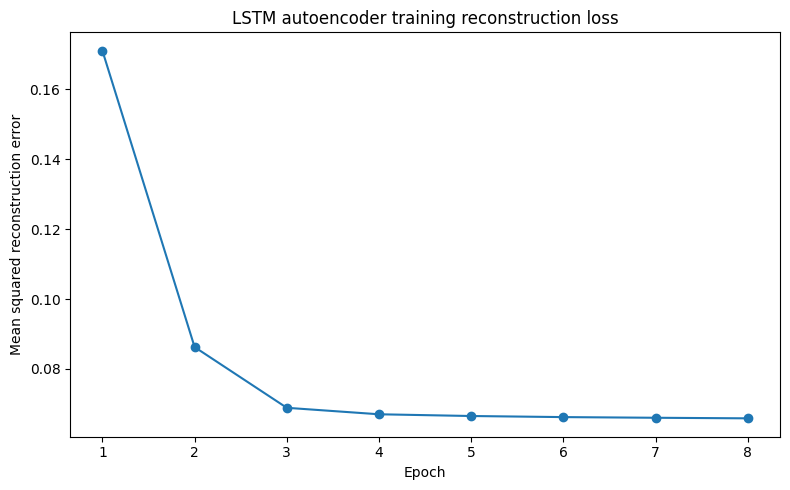

Saved: /kaggle/working/autospectra_week06_outputs/plots/training_lstm_autoencoder.png


,Direction,Threshold,Validation_Precision,Validation_Recall,Validation_F1,Validation_Accuracy,Validation_FPR
238,higher_is_attack,0.068801,0.962237,0.629062,0.760771,0.6835,0.09875


,Value
Model,LSTM Autoencoder (binary)
Threshold_Method,Validation_F1_with_FPR_constraint
Score_Direction,higher_is_attack
Threshold,0.068801
Accuracy,0.681
Precision,0.957659
Recall,0.629062
F1,0.759336
ROC_AUC,0.71011
PR_AUC,0.931081


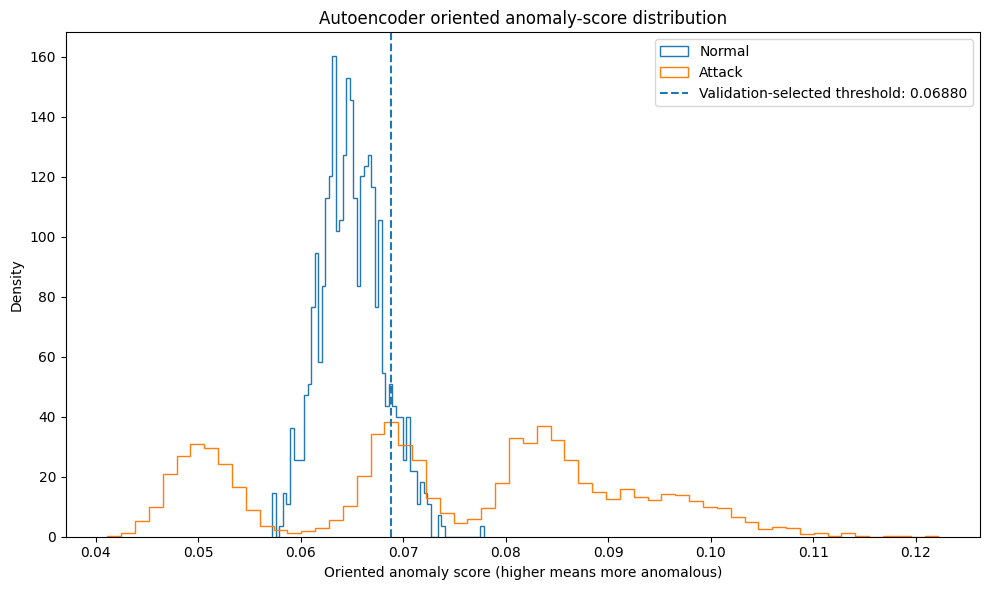

Saved: /kaggle/working/autospectra_week06_outputs/plots/autoencoder_score_distribution.png


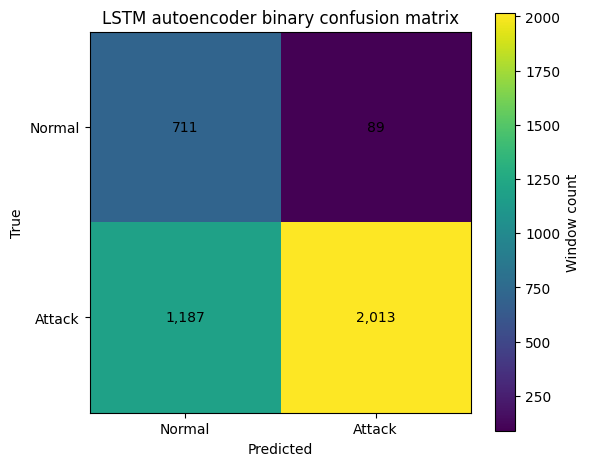

Saved: /kaggle/working/autospectra_week06_outputs/plots/autoencoder_confusion_matrix.png


In [102]:

# 13B. Train and evaluate the normal-only LSTM autoencoder


autoencoder_results = None


def apply_anomaly_rule(
    scores,
    threshold,
    direction,
):
    """Convert reconstruction scores to 0=normal / 1=attack."""
    if direction == "higher_is_attack":
        return (
            np.asarray(scores)
            >= threshold
        ).astype(int)

    if direction == "lower_is_attack":
        return (
            np.asarray(scores)
            <= threshold
        ).astype(int)

    raise ValueError(
        f"Unknown anomaly direction: {direction}"
    )


def select_validation_anomaly_rule(
    y_binary,
    scores,
    maximum_fpr=0.10,
):
    """
    Select threshold and score direction using validation data only.

    A normal-only autoencoder normally gives attacks higher errors, but some
    feature distributions can reverse that relationship. Both orientations
    are evaluated transparently. The test set is never used for selection.
    """
    y_binary = np.asarray(
        y_binary,
        dtype=int,
    )
    scores = np.asarray(
        scores,
        dtype=float,
    )

    if set(np.unique(y_binary)) != {0, 1}:
        raise ValueError(
            "Validation data must contain both normal and attack windows."
        )

    quantile_grid = np.linspace(
        0.001,
        0.999,
        500,
    )
    candidates = np.unique(
        np.quantile(
            scores,
            quantile_grid,
        )
    )

    rows = []

    for direction in [
        "higher_is_attack",
        "lower_is_attack",
    ]:
        for threshold in candidates:
            predictions = apply_anomaly_rule(
                scores,
                float(threshold),
                direction,
            )

            tn, fp, fn, tp = confusion_matrix(
                y_binary,
                predictions,
                labels=[0, 1],
            ).ravel()

            fpr = fp / max(
                fp + tn,
                1,
            )

            rows.append({
                "direction": direction,
                "threshold": float(threshold),
                "precision": precision_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_binary,
                    predictions,
                    zero_division=0,
                ),
                "accuracy": accuracy_score(
                    y_binary,
                    predictions,
                ),
                "fpr": fpr,
            })

    search_df = pd.DataFrame(rows)

    constrained = search_df[
        search_df["fpr"]
        <= maximum_fpr
    ]

    selection_pool = (
        constrained
        if not constrained.empty
        else search_df
    )

    selected = (
        selection_pool
        .sort_values(
            [
                "f1",
                "recall",
                "precision",
                "accuracy",
                "fpr",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    return selected, search_df


if RUN_AUTOENCODER:
    normal_training_sequences = X_train_seq[
        y_train
        == CLASS_TO_INDEX["Normal"]
    ]

    if len(normal_training_sequences) == 0:
        raise RuntimeError(
            "No normal training windows were found."
        )

    autoencoder_train_loader = DataLoader(
        SequenceOnlyDataset(
            normal_training_sequences
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    autoencoder = LSTMSequenceAutoencoder()

    fit_start = time.perf_counter()

    (
        autoencoder,
        autoencoder_history,
    ) = train_autoencoder(
        autoencoder,
        autoencoder_train_loader,
    )

    autoencoder_fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        autoencoder_history["epoch"],
        autoencoder_history[
            "reconstruction_loss"
        ],
        marker="o",
    )
    plt.title(
        "LSTM autoencoder training "
        "reconstruction loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel(
        "Mean squared reconstruction error"
    )
    save_current_figure(
        "training_lstm_autoencoder.png"
    )

    autoencoder_path = (
        MODEL_DIR
        / "lstm_autoencoder.pt"
    )

    torch.save({
        "state_dict":
            autoencoder.state_dict(),
        "window_size": WINDOW_SIZE,
        "input_size": 11,
    }, autoencoder_path)

    validation_scores = autoencoder_scores(
        autoencoder,
        X_validation_seq,
    )

    test_score_start = time.perf_counter()

    test_scores = autoencoder_scores(
        autoencoder,
        X_test_seq,
    )

    autoencoder_inference_seconds = (
        time.perf_counter()
        - test_score_start
    )

    y_validation_binary = (
        y_validation
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    y_test_binary = (
        y_test
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    if set(
        np.unique(
            y_validation_binary
        )
    ) != {0, 1}:
        raise RuntimeError(
            "The validation split must contain normal and attack windows."
        )

    if set(
        np.unique(
            y_test_binary
        )
    ) != {0, 1}:
        raise RuntimeError(
            "The test split must contain normal and attack windows."
        )

    selected_rule, threshold_search_df = (
        select_validation_anomaly_rule(
            y_validation_binary,
            validation_scores,
            maximum_fpr=0.10,
        )
    )

    selected_threshold = float(
        selected_rule["threshold"]
    )
    selected_direction = str(
        selected_rule["direction"]
    )

    display(
        pd.DataFrame(
            [selected_rule]
        ).rename(
            columns={
                "direction":
                    "Direction",
                "threshold":
                    "Threshold",
                "precision":
                    "Validation_Precision",
                "recall":
                    "Validation_Recall",
                "f1":
                    "Validation_F1",
                "accuracy":
                    "Validation_Accuracy",
                "fpr":
                    "Validation_FPR",
            }
        )
    )

    threshold_config_path = (
        MODEL_DIR
        / "autoencoder_threshold.json"
    )

    with threshold_config_path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump({
            "threshold":
                selected_threshold,
            "direction":
                selected_direction,
            "selected_on":
                "validation set",
            "maximum_validation_fpr":
                0.10,
        }, handle, indent=2)

    autoencoder_test_prediction = (
        apply_anomaly_rule(
            test_scores,
            selected_threshold,
            selected_direction,
        )
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_binary,
        autoencoder_test_prediction,
        labels=[0, 1],
    ).ravel()

    oriented_validation_scores = (
        validation_scores
        if selected_direction
        == "higher_is_attack"
        else -validation_scores
    )

    oriented_test_scores = (
        test_scores
        if selected_direction
        == "higher_is_attack"
        else -test_scores
    )

    autoencoder_results = {
        "Model":
            "LSTM Autoencoder (binary)",
        "Threshold_Method":
            "Validation_F1_with_FPR_constraint",
        "Score_Direction":
            selected_direction,
        "Threshold":
            selected_threshold,
        "Accuracy":
            accuracy_score(
                y_test_binary,
                autoencoder_test_prediction,
            ),
        "Precision":
            precision_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "Recall":
            recall_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "F1":
            f1_score(
                y_test_binary,
                autoencoder_test_prediction,
                zero_division=0,
            ),
        "ROC_AUC":
            roc_auc_score(
                y_test_binary,
                oriented_test_scores,
            ),
        "PR_AUC":
            average_precision_score(
                y_test_binary,
                oriented_test_scores,
            ),
        "FPR":
            fp / max(fp + tn, 1),
        "FNR":
            fn / max(fn + tp, 1),
        "Inference_ms_per_window":
            autoencoder_inference_seconds
            * 1000
            / len(y_test_binary),
        "Model_Size_MB":
            model_file_size_mb(
                autoencoder_path
            ),
        "Training_Seconds":
            autoencoder_fit_seconds,
    }

    display(
        pd.DataFrame(
            [autoencoder_results]
        )
        .T
        .rename(
            columns={0: "Value"}
        )
    )

    # Save the complete validation threshold search for auditability.
    threshold_search_df.to_csv(
        REPORT_DIR
        / "autoencoder_threshold_search.csv",
        index=False,
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        oriented_test_scores[
            y_test_binary == 0
        ],
        bins=60,
        density=True,
        histtype="step",
        label="Normal",
    )

    plt.hist(
        oriented_test_scores[
            y_test_binary == 1
        ],
        bins=60,
        density=True,
        histtype="step",
        label="Attack",
    )

    oriented_threshold = (
        selected_threshold
        if selected_direction
        == "higher_is_attack"
        else -selected_threshold
    )

    plt.axvline(
        oriented_threshold,
        linestyle="--",
        label=(
            "Validation-selected threshold: "
            f"{oriented_threshold:.5f}"
        ),
    )

    plt.title(
        "Autoencoder oriented anomaly-score "
        "distribution"
    )
    plt.xlabel(
        "Oriented anomaly score "
        "(higher means more anomalous)"
    )
    plt.ylabel("Density")
    plt.legend()

    save_current_figure(
        "autoencoder_score_distribution.png"
    )

    matrix = confusion_matrix(
        y_test_binary,
        autoencoder_test_prediction,
        labels=[0, 1],
    )

    plt.figure(figsize=(6, 5))
    image = plt.imshow(matrix)
    plt.colorbar(
        image,
        label="Window count",
    )
    plt.xticks(
        [0, 1],
        ["Normal", "Attack"],
    )
    plt.yticks(
        [0, 1],
        ["Normal", "Attack"],
    )

    for row_index in range(2):
        for column_index in range(2):
            plt.text(
                column_index,
                row_index,
                f"{matrix[row_index, column_index]:,}",
                ha="center",
                va="center",
            )

    plt.title(
        "LSTM autoencoder "
        "binary confusion matrix"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")

    save_current_figure(
        "autoencoder_confusion_matrix.png"
    )


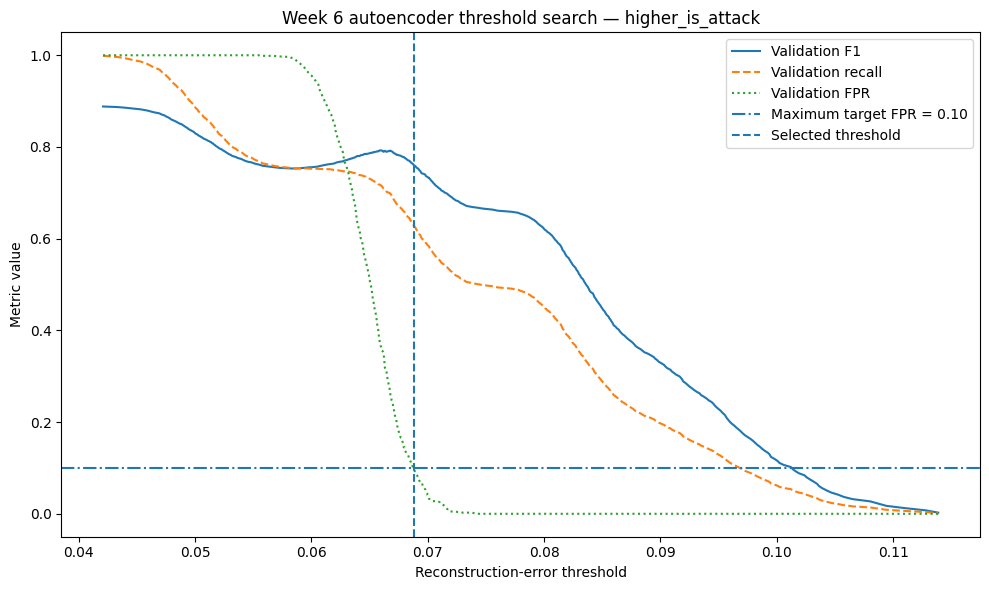

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_autoencoder_threshold_search_higher_is_attack.png


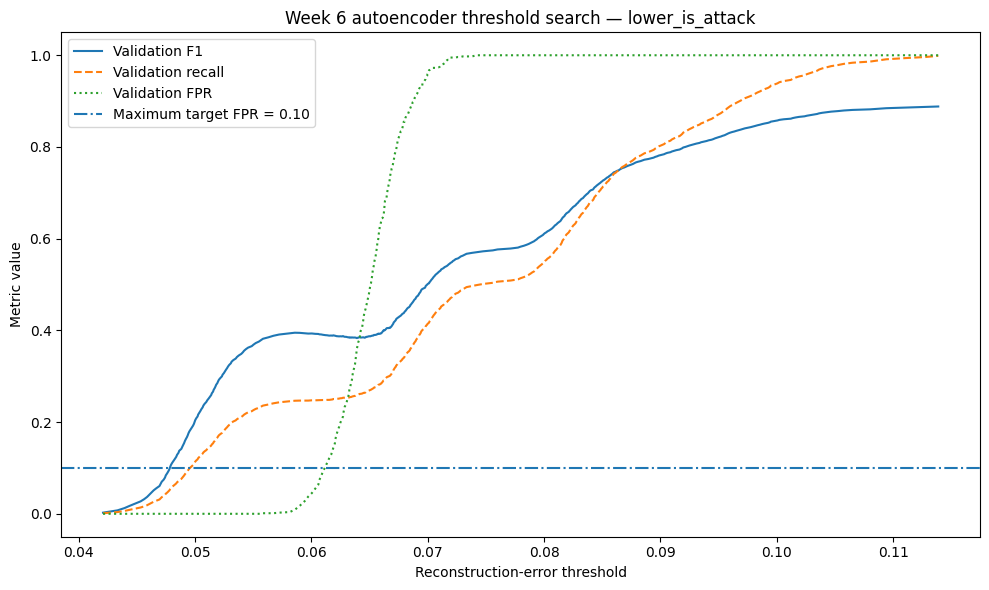

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_autoencoder_threshold_search_lower_is_attack.png


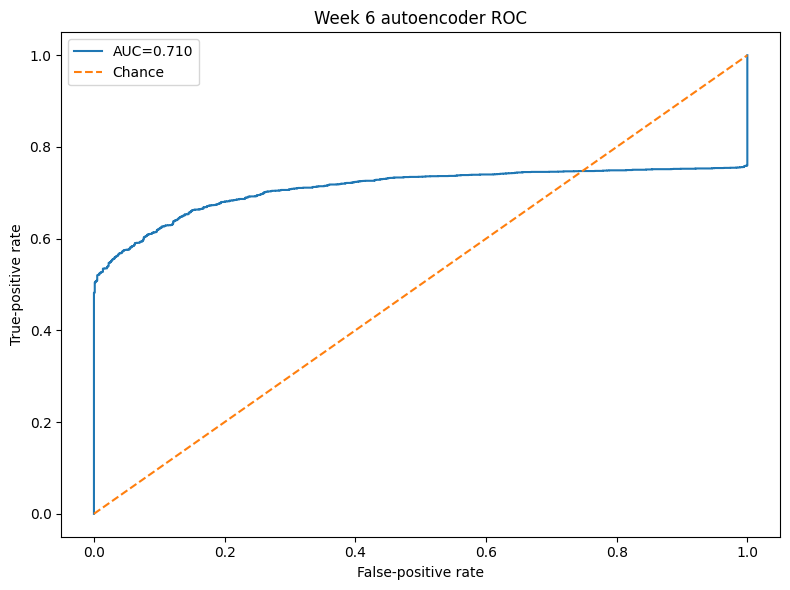

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_autoencoder_roc.png


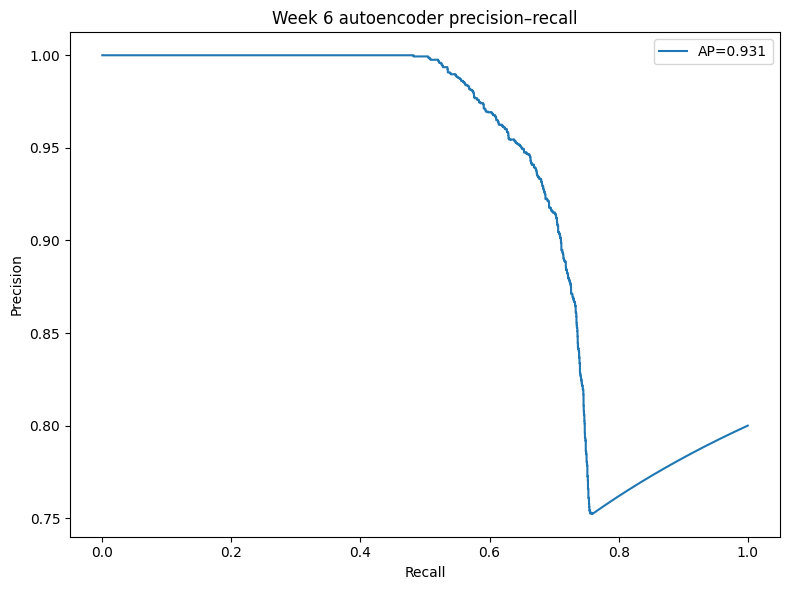

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_autoencoder_precision_recall.png


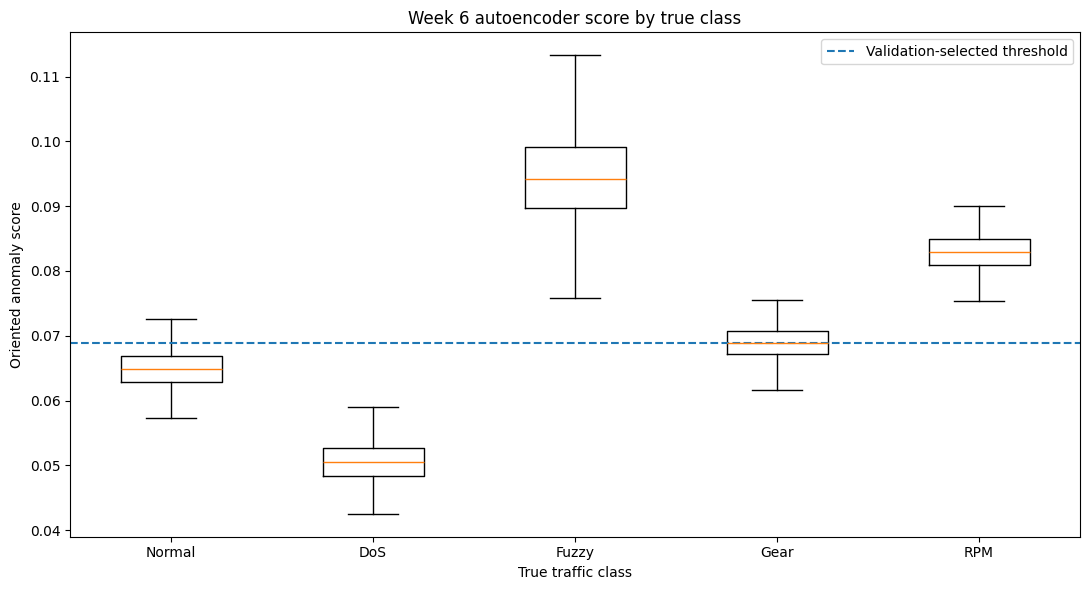

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_autoencoder_score_by_class.png


In [103]:
# 12. Additional autoencoder threshold, ROC, PR and class-score evidence

for direction in ["higher_is_attack", "lower_is_attack"]:
    subset = threshold_search_df[
        threshold_search_df["direction"] == direction
    ].sort_values("threshold")

    plt.figure(figsize=(10, 6))
    plt.plot(subset["threshold"], subset["f1"], label="Validation F1")
    plt.plot(subset["threshold"], subset["recall"], linestyle="--", label="Validation recall")
    plt.plot(subset["threshold"], subset["fpr"], linestyle=":", label="Validation FPR")
    plt.axhline(0.10, linestyle="-.", label="Maximum target FPR = 0.10")

    if direction == selected_direction:
        plt.axvline(
            selected_threshold,
            linestyle="--",
            label="Selected threshold",
        )

    plt.xlabel("Reconstruction-error threshold")
    plt.ylabel("Metric value")
    plt.title(f"Week 6 autoencoder threshold search — {direction}")
    plt.legend()
    save_current_figure(
        f"week06_autoencoder_threshold_search_{direction}.png"
    )

ae_fpr, ae_tpr, _ = roc_curve(
    y_test_binary,
    oriented_test_scores,
)
plt.figure(figsize=(8, 6))
plt.plot(
    ae_fpr,
    ae_tpr,
    label=f"AUC={roc_auc_score(y_test_binary, oriented_test_scores):.3f}",
)
plt.plot([0,1],[0,1], linestyle="--", label="Chance")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("Week 6 autoencoder ROC")
plt.legend()
save_current_figure("week06_autoencoder_roc.png")

ae_precision, ae_recall, _ = precision_recall_curve(
    y_test_binary,
    oriented_test_scores,
)
plt.figure(figsize=(8, 6))
plt.plot(
    ae_recall,
    ae_precision,
    label=f"AP={average_precision_score(y_test_binary, oriented_test_scores):.3f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Week 6 autoencoder precision–recall")
plt.legend()
save_current_figure("week06_autoencoder_precision_recall.png")

score_by_class = [
    oriented_test_scores[y_test == class_index]
    for class_index in range(len(CLASS_NAMES))
]
plt.figure(figsize=(11, 6))
plt.boxplot(
    score_by_class,
    labels=CLASS_NAMES,
    showfliers=False,
)
plt.axhline(
    oriented_threshold,
    linestyle="--",
    label="Validation-selected threshold",
)
plt.xlabel("True traffic class")
plt.ylabel("Oriented anomaly score")
plt.title("Week 6 autoencoder score by true class")
plt.legend()
save_current_figure("week06_autoencoder_score_by_class.png")

autoencoder_prediction_df = metadata_test.copy()
autoencoder_prediction_df["true_class"] = [CLASS_NAMES[i] for i in y_test]
autoencoder_prediction_df["binary_true"] = y_test_binary
autoencoder_prediction_df["anomaly_score_raw"] = test_scores
autoencoder_prediction_df["anomaly_score_oriented"] = oriented_test_scores
autoencoder_prediction_df["binary_prediction"] = autoencoder_test_prediction
autoencoder_prediction_df["oriented_threshold"] = oriented_threshold
autoencoder_prediction_df.to_csv(
    REPORT_DIR / "week06_autoencoder_predictions.csv",
    index=False,
)

pd.DataFrame([autoencoder_results]).to_csv(
    REPORT_DIR / "week06_autoencoder_metrics.csv",
    index=False,
)

# Part D — Supervised vs Unsupervised Attack Detection

,Model,Precision,Recall,F1,FPR,FNR
0,Bidirectional LSTM,1.000000,0.994375,0.997180,0.00000,0.005625
1,LSTM Autoencoder,0.957659,0.629062,0.759336,0.11125,0.370937


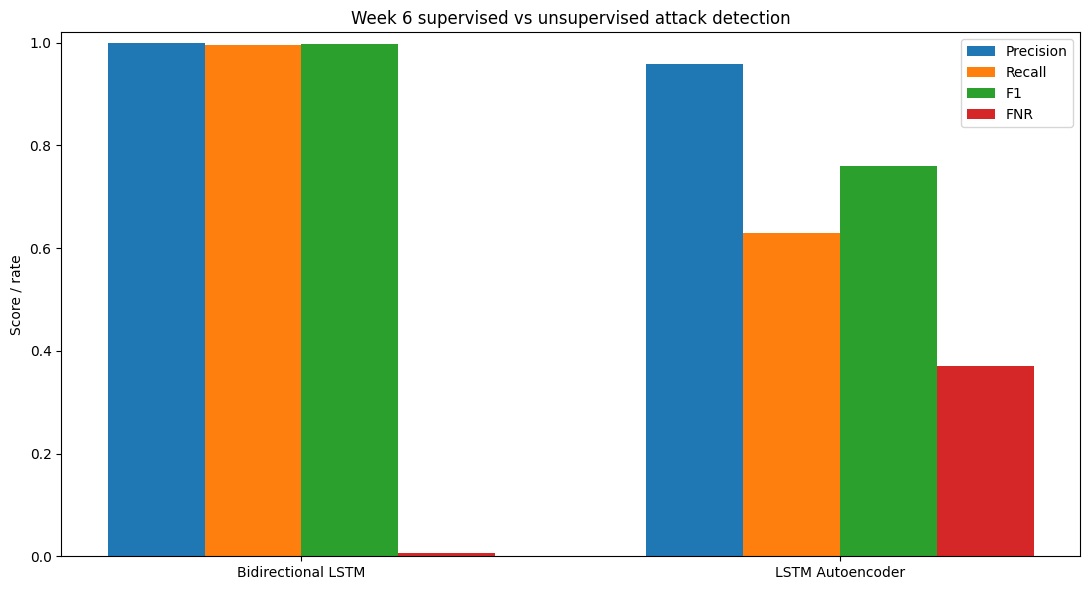

Saved: /kaggle/working/autospectra_week06_outputs/plots/week06_supervised_unsupervised_comparison.png


In [104]:
# 13. Binary attack-detection comparison

lstm_binary_prediction = (
    lstm_predictions != CLASS_TO_INDEX["Normal"]
).astype(int)

def binary_summary(model_name, prediction):
    tn, fp, fn, tp = confusion_matrix(
        y_test_binary,
        prediction,
        labels=[0,1],
    ).ravel()

    return {
        "Model": model_name,
        "Precision": precision_score(
            y_test_binary,
            prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_test_binary,
            prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            y_test_binary,
            prediction,
            zero_division=0,
        ),
        "FPR": fp / max(fp + tn, 1),
        "FNR": fn / max(fn + tp, 1),
    }

binary_comparison_df = pd.DataFrame([
    binary_summary("Bidirectional LSTM", lstm_binary_prediction),
    binary_summary("LSTM Autoencoder", autoencoder_test_prediction),
])
display(binary_comparison_df)
binary_comparison_df.to_csv(
    REPORT_DIR / "week06_supervised_unsupervised_comparison.csv",
    index=False,
)

x = np.arange(len(binary_comparison_df))
width = 0.18
plt.figure(figsize=(11, 6))
plt.bar(x-1.5*width, binary_comparison_df["Precision"], width=width, label="Precision")
plt.bar(x-0.5*width, binary_comparison_df["Recall"], width=width, label="Recall")
plt.bar(x+0.5*width, binary_comparison_df["F1"], width=width, label="F1")
plt.bar(x+1.5*width, binary_comparison_df["FNR"], width=width, label="FNR")
plt.xticks(x, binary_comparison_df["Model"])
plt.ylim(0, 1.02)
plt.ylabel("Score / rate")
plt.title("Week 6 supervised vs unsupervised attack detection")
plt.legend()
save_current_figure(
    "week06_supervised_unsupervised_comparison.png"
)

# Part E — Week 6 Artifact and Image Export

In [105]:
# 14. Export model metadata, image manifest and downloadable ZIP files
import zipfile
from pathlib import Path

lstm_metadata = {
    "model": "Bidirectional LSTM Classifier",
    "class_names": CLASS_NAMES,
    "window_size": WINDOW_SIZE,
    "input_size": 11,
    "hidden_size": 64,
    "bidirectional": True,
    "selected_on": "validation macro-F1",
    "test_used_for_selection": False,
}

autoencoder_metadata = {
    "model": "LSTM Autoencoder",
    "mode": "binary anomaly detection",
    "training_data": "Normal training windows only",
    "window_size": WINDOW_SIZE,
    "input_size": 11,
    "hidden_size": 48,
    "threshold": selected_threshold,
    "score_direction": selected_direction,
    "oriented_threshold": oriented_threshold,
    "threshold_selected_on": "validation set only",
    "maximum_validation_fpr": 0.10,
    "test_used_for_threshold_selection": False,
}

demo_handover = {
    "class_names": CLASS_NAMES,
    "sequence_shape": [WINDOW_SIZE, 11],
    "lstm_model_file": "lstm_classifier.pt",
    "autoencoder_model_file": "lstm_autoencoder.pt",
    "lstm_predictions": "week06_lstm_predictions.csv",
    "autoencoder_predictions": "week06_autoencoder_predictions.csv",
    "high_confidence_errors": "week06_high_confidence_lstm_errors.csv",
    "human_oversight_required": True,
    "automatic_vehicle_control": False,
}

for filename, payload in [
    ("week06_lstm_metadata.json", lstm_metadata),
    ("week06_autoencoder_metadata.json", autoencoder_metadata),
    ("week06_demo_handover.json", demo_handover),
]:
    with (REPORT_DIR / filename).open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)

week6_summary = {
    "project": "AutoSPECTRA",
    "week": 6,
    "scope": "Bidirectional LSTM and normal-only LSTM autoencoder",
    "split_strategy": SPLIT_STRATEGY,
    "sequence_shape": [WINDOW_SIZE, 11],
    "lstm_metrics": lstm_metrics_df.iloc[0].to_dict(),
    "autoencoder_metrics": autoencoder_results,
    "fusion_performed": False,
    "next_week": "Fusion, calibration, ablation and latency analysis",
}

with (REPORT_DIR / "week06_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(
        week6_summary,
        handle,
        indent=2,
        default=lambda x: float(x) if isinstance(x, np.generic) else str(x),
    )

image_files = sorted(PLOT_DIR.glob("*.png"))

image_manifest_df = pd.DataFrame([
    {
        "Image": path.name,
        "Size_KB": round(path.stat().st_size / 1024, 2),
        "Kaggle_Path": str(path),
    }
    for path in image_files
])
display(image_manifest_df)
image_manifest_df.to_csv(
    REPORT_DIR / "week06_image_manifest.csv",
    index=False,
)

images_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week06_Images.zip"
)

with zipfile.ZipFile(
    images_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for path in image_files:
        archive.write(path, arcname=path.name)

evidence_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week06_Evidence.zip"
)

with zipfile.ZipFile(
    evidence_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for directory in [REPORT_DIR, PLOT_DIR]:
        for path in directory.rglob("*"):
            if path.is_file():
                archive.write(
                    path,
                    arcname=path.relative_to(OUTPUT_DIR),
                )

print("=" * 90)
print("AUTOSPECTRA WEEK 6 COMPLETE")
print("=" * 90)
print("Images saved:", len(image_files))
print("Images ZIP:", images_zip)
print("Evidence ZIP:", evidence_zip)

,Image,Size_KB,Kaggle_Path
0,autoencoder_confusion_matrix.png,59.26,/kaggle/working/autospectra_week06_outputs/plo...
1,autoencoder_score_distribution.png,82.29,/kaggle/working/autospectra_week06_outputs/plo...
2,metrics_calibration_lstm_classifier.png,91.68,/kaggle/working/autospectra_week06_outputs/plo...
3,metrics_confusion_lstm_classifier.png,90.88,/kaggle/working/autospectra_week06_outputs/plo...
4,metrics_pr_lstm_classifier.png,84.69,/kaggle/working/autospectra_week06_outputs/plo...
5,metrics_roc_lstm_classifier.png,111.89,/kaggle/working/autospectra_week06_outputs/plo...
6,training_lstm_autoencoder.png,65.80,/kaggle/working/autospectra_week06_outputs/plo...
7,training_lstm_classifier.png,95.08,/kaggle/working/autospectra_week06_outputs/plo...
8,week06_autoencoder_precision_recall.png,63.47,/kaggle/working/autospectra_week06_outputs/plo...
9,week06_autoencoder_roc.png,77.41,/kaggle/working/autospectra_week06_outputs/plo...


AUTOSPECTRA WEEK 6 COMPLETE
Images saved: 17
Images ZIP: /kaggle/working/AutoSPECTRA_Week06_Images.zip
Evidence ZIP: /kaggle/working/AutoSPECTRA_Week06_Evidence.zip


# Week 6 Completion Summary

Week 6 now provides both sequence-learning routes:

- **Bidirectional LSTM:** supervised five-class classification.
- **LSTM autoencoder:** binary anomaly detection trained on Normal traffic only.

The LSTM checkpoint is selected using validation macro-F1. The autoencoder threshold and score direction are selected using validation data only, with a validation FPR constraint. The held-out test set is used only after those choices are fixed.

Prediction-level CSVs and metadata JSON files are exported for later error analysis and Week 8 demonstration integration.

## Kaggle downloads

```text
/kaggle/working/AutoSPECTRA_Week06_Images.zip
/kaggle/working/AutoSPECTRA_Week06_Evidence.zip
```

## Week 7 Handover

Week 7 will perform validation-weighted fusion, confidence calibration, ablations, latency analysis and final cross-model comparison.